In [44]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
from geolocalizar_desde_csv import cargar_ips, geolocalizar_ips, generar_mapa, ranking_paises

In [42]:
#CONSTANTS
 
top_n = 20

#FUNCTION DEFINITIONS

#Load data from CSV file

def load_data(file_path):
    df = pd.read_csv(file_path)
    return df


#Top users
def top_users(df, top_n):
    top_users = df['username'].value_counts().head(top_n)
    return top_users

#Top passwords
def top_passwords(df, top_n):
    top_passwords = df['password'].value_counts().head(top_n)
    return top_passwords

#Top user and password combinations
def top_user_password_combinations(df, top_n):
    top_combinations = df.groupby(['username', 'password']).size().sort_values(ascending=False).head(top_n)
    return top_combinations.reset_index(name="veces")





In [ ]:
#DATAFRAMES

users_passwords = load_data('/home/benjaminjerez/Documents/honeypot/data/users_passwords.csv')
inputs = load_data('/home/benjaminjerez/Documents/honeypot/data/inputs.csv')


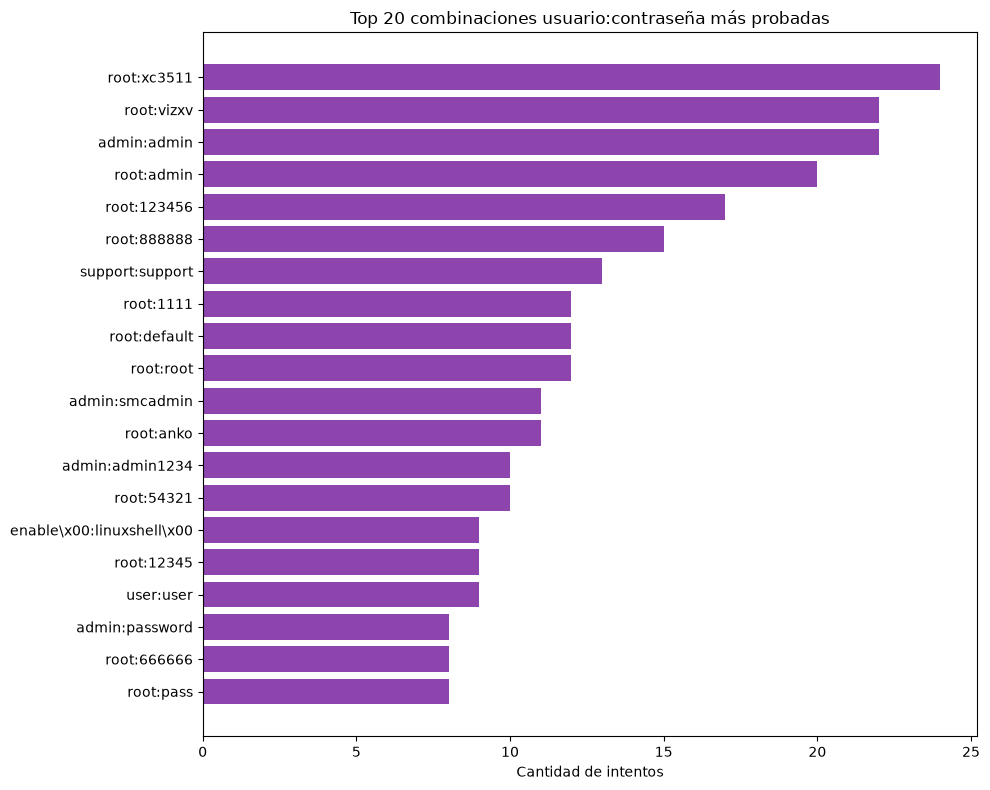

In [ ]:
#PLOTS


#Combination of top users and passwords plot

def graficar_combinaciones(top_combos, archivo_salida="top_combinaciones.png"):
    etiquetas = top_combos.apply(lambda r: f"{r['username']}:{r['password']}", axis=1)
    plt.figure(figsize=(10, 8))
    plt.barh(etiquetas[::-1], top_combos["veces"][::-1], color="#8e44ad")
    plt.title(f"Top {len(top_combos)} combinaciones usuario:contraseña más probadas")
    plt.xlabel("Cantidad de intentos")
    plt.tight_layout()
    plt.savefig(archivo_salida, dpi=150)
    plt.show()   # <-- esto lo muestra inline en la celda del notebook

top_combos = top_user_password_combinations(users_passwords, top_n)
graficar = graficar_combinaciones(top_combos)



In [46]:
df_ips = cargar_ips('/home/benjaminjerez/Documents/honeypot/data/unique_ips.csv')
df_geo = geolocalizar_ips(df_ips["ip"].tolist())
df_final = df_geo.merge(df_ips, left_on="query", right_on="ip", how="left")

ranking = ranking_paises(df_final)
generar_mapa(df_final)  # genera mapa_ataques.html

IPs únicas cargadas: 38
Procesadas 38/38 IPs...

=== TOP 15 PAÍSES DE ORIGEN DE ATAQUES ===
        country  intentos
      Australia      3189
       Pakistan        27
  United States        24
The Netherlands         5
          China         5
        Ukraine         4
          Chile         3
        Türkiye         2
         Russia         2
      Argentina         1
     Guadeloupe         1
          Egypt         1
       Colombia         1
      Hong Kong         1
          Spain         1

Mapa guardado en: mapa_ataques.html


/home/benjaminjerez/.local/lib/python3.14/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore
